<a href="https://colab.research.google.com/github/kyokux2/Laboratorio3token/blob/main/WordTokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install torch numpy matplotlib tqdm requests

In [40]:
import os
import math
import time
import random
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

In [41]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [42]:
url = "https://www.gutenberg.org/files/11/11-0.txt"
path = "input.txt"

if not os.path.exists(path):
    response = requests.get(url)
    response.raise_for_status()

    with open(path, "w", encoding="utf-8") as f:
        f.write(response.text)

with open(path, "r", encoding="utf-8") as f:
    text = f.read()

print("Longitud del texto:", len(text))
print(text[:1000])

Longitud del texto: 144696
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So

In [43]:
text = text.lower()

start_marker = "*** start of the project gutenberg ebook"
end_marker = "*** end of the project gutenberg ebook"

start_idx = text.find(start_marker)
end_idx = text.find(end_marker)

if start_idx != -1:
    text = text[start_idx:]

if end_idx != -1:
    text = text[:end_idx]

print("Longitud después de limpieza:", len(text))
print(text[:1000])

Longitud después de limpieza: 144650
*** start of the project gutenberg ebook 11 ***

[illustration]




alice’s adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3.0

contents

 chapter i.     down the rabbit-hole
 chapter ii.    the pool of tears
 chapter iii.   a caucus-race and a long tale
 chapter iv.    the rabbit sends in a little bill
 chapter v.     advice from a caterpillar
 chapter vi.    pig and pepper
 chapter vii.   a mad tea-party
 chapter viii.  the queen’s croquet-ground
 chapter ix.    the mock turtle’s story
 chapter x.     the lobster quadrille
 chapter xi.    who stole the tarts?
 chapter xii.   alice’s evidence




chapter i.
down the rabbit-hole


alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought alice
“without pictures or conversat

In [44]:
import re

def tokenize_words(text):
    """
    Tokenización por palabras y signos de puntuación.
    Ejemplo:
    "hello, world!" -> ["hello", ",", "world", "!"]
    """
    return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

tokens = tokenize_words(text)

vocab = sorted(list(set(tokens)))
vocab_size = len(vocab)

stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: token for token, i in stoi.items()}

def encode(token_list):
    return [stoi[token] for token in token_list]

def decode(ids):
    tokens_decoded = [itos[i] for i in ids]

    text_decoded = ""

    for token in tokens_decoded:
        if token in [".", ",", "!", "?", ":", ";", "'", '"', ")", "]", "}"]:
            text_decoded += token
        elif token in ["(", "[", "{"]:
            text_decoded += " " + token
        else:
            text_decoded += " " + token

    return text_decoded.strip()

print("Número total de tokens:", len(tokens))
print("Tamaño del vocabulario:", vocab_size)
print(tokens[:100])

Número total de tokens: 35532
Tamaño del vocabulario: 2712
['*', '*', '*', 'start', 'of', 'the', 'project', 'gutenberg', 'ebook', '11', '*', '*', '*', '[', 'illustration', ']', 'alice', '’', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3', '.', '0', 'contents', 'chapter', 'i', '.', 'down', 'the', 'rabbit', '-', 'hole', 'chapter', 'ii', '.', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', '.', 'a', 'caucus', '-', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', '.', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', '.', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', '.', 'pig', 'and', 'pepper', 'chapter', 'vii', '.', 'a', 'mad', 'tea', '-', 'party', 'chapter', 'viii', '.', 'the', 'queen', '’', 's', 'croquet', '-', 'ground']


In [45]:
data = torch.tensor(encode(tokens), dtype=torch.long)

train_size = int(0.9 * len(data))
train_data = data[:train_size]
val_data = data[train_size:]

block_size = 32
batch_size = 64

def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(len(source) - block_size - 1, (batch_size,))

    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])

    x = x.to(device)
    y = y.to(device)

    return x, y

x, y = get_batch("train")

print(x.shape)
print(y.shape)
print(decode(x[0].tolist()))
print("---- TARGET ----")
print(decode(y[0].tolist()))

torch.Size([64, 32])
torch.Size([64, 32])
howling alternately without a moment ’ s pause. the only things in the kitchen that did not sneeze, were the cook, and a large cat which was sitting on
---- TARGET ----
alternately without a moment ’ s pause. the only things in the kitchen that did not sneeze, were the cook, and a large cat which was sitting on the


In [46]:
@torch.no_grad()
def estimate_loss(model, eval_iters=50):
    results = {}

    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()

        results[split] = losses.mean().item()

    model.train()
    return results

In [47]:
def train_model(model, model_name, max_iters=1000, eval_interval=200, learning_rate=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        "model": [],
        "iter": [],
        "train_loss": [],
        "val_loss": [],
        "train_perplexity": [],
        "val_perplexity": []
    }

    model.train()

    for iteration in range(max_iters + 1):

        if iteration % eval_interval == 0:
            losses = estimate_loss(model)

            train_loss = losses["train"]
            val_loss = losses["val"]

            train_ppl = math.exp(train_loss)
            val_ppl = math.exp(val_loss)

            history["model"].append(model_name)
            history["iter"].append(iteration)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_perplexity"].append(train_ppl)
            history["val_perplexity"].append(val_ppl)

            print(
                f"{model_name} | iter {iteration}: "
                f"train loss {train_loss:.4f}, val loss {val_loss:.4f}, "
                f"train ppl {train_ppl:.2f}, val ppl {val_ppl:.2f}"
            )

        x, y = get_batch("train")

        logits, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

    return history

In [48]:
class SimpleRNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.rnn(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [49]:
simple_rnn = SimpleRNNLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1
).to(device)

print("Número de parámetros:", sum(p.numel() for p in simple_rnn.parameters()))

history_simple_rnn = train_model(
    model=simple_rnn,
    model_name="Simple RNN",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1142936
Simple RNN | iter 0: train loss 7.9311, val loss 7.9340, train ppl 2782.38, val ppl 2790.43
Simple RNN | iter 200: train loss 4.9292, val loss 5.2099, train ppl 138.27, val ppl 183.08
Simple RNN | iter 400: train loss 4.2627, val loss 4.8621, train ppl 71.00, val ppl 129.30
Simple RNN | iter 600: train loss 3.8097, val loss 4.6986, train ppl 45.14, val ppl 109.79
Simple RNN | iter 800: train loss 3.4599, val loss 4.6898, train ppl 31.81, val ppl 108.83
Simple RNN | iter 1000: train loss 3.1703, val loss 4.7030, train ppl 23.81, val ppl 110.28


In [50]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = simple_rnn.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_simple_rnn = decode(generated_ids[0].tolist())

print(generated_text_simple_rnn)

! ” said alice. “ he poured your pardon, ” said the hatter, however poor alice, as it was going behind to do, and the two began to itself, and was going to dive as she was ready to make her look. her fancy and once repeated to be was in the same of the trees. “ twenty! ” “ i ’ m mad, and i ’ ve got to me than the mouse? ” “ and this, you know, ” the gryphon replied in half against at once. “ there ’ s a cat, ” said alice. “ what a dog sort, ” alice cautiously hatter, “ the darkness came into a porpoise, ” the duchess was, but she began down, and the dormouse was delighted in the tone. “ if you are old, ” said the little door: then she made that with all growing; and alice ’ s an old crab of it, and rapped. “ i ’ m a _very_ remarkable as i to get hold of a cheap one, ” the gryphon went on, “ you don ’ t you, ” the gryphon angrily, and she went on in the wood conclusion, and was them like about her been; the executioner was the first, pointing to her, “ i didn ’ t you, ” it was a little 

In [51]:
generated_samples = {}

generated_samples["Simple RNN"] = generated_text_simple_rnn

print(generated_samples["Simple RNN"])

! ” said alice. “ he poured your pardon, ” said the hatter, however poor alice, as it was going behind to do, and the two began to itself, and was going to dive as she was ready to make her look. her fancy and once repeated to be was in the same of the trees. “ twenty! ” “ i ’ m mad, and i ’ ve got to me than the mouse? ” “ and this, you know, ” the gryphon replied in half against at once. “ there ’ s a cat, ” said alice. “ what a dog sort, ” alice cautiously hatter, “ the darkness came into a porpoise, ” the duchess was, but she began down, and the dormouse was delighted in the tone. “ if you are old, ” said the little door: then she made that with all growing; and alice ’ s an old crab of it, and rapped. “ i ’ m a _very_ remarkable as i to get hold of a cheap one, ” the gryphon went on, “ you don ’ t you, ” the gryphon angrily, and she went on in the wood conclusion, and was them like about her been; the executioner was the first, pointing to her, “ i didn ’ t you, ” it was a little 

In [52]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1, bidirectional=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        direction_factor = 2 if bidirectional else 1

        self.fc = nn.Linear(hidden_dim * direction_factor, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.lstm(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [53]:
lstm_1_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_1_layer.parameters()))

history_lstm_1_layer = train_model(
    model=lstm_1_layer,
    model_name="LSTM 1 layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1439384
LSTM 1 layer | iter 0: train loss 7.9105, val loss 7.9136, train ppl 2725.78, val ppl 2734.12
LSTM 1 layer | iter 200: train loss 5.2690, val loss 5.4657, train ppl 194.22, val ppl 236.45
LSTM 1 layer | iter 400: train loss 4.7402, val loss 5.0968, train ppl 114.46, val ppl 163.49
LSTM 1 layer | iter 600: train loss 4.3872, val loss 4.9267, train ppl 80.41, val ppl 137.92
LSTM 1 layer | iter 800: train loss 4.1468, val loss 4.8425, train ppl 63.23, val ppl 126.79
LSTM 1 layer | iter 1000: train loss 3.9205, val loss 4.7681, train ppl 50.42, val ppl 117.70


In [54]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_1_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_1_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_1_layer)

! ” said alice, “ if they he, ” thought alice. “ and i ’ s _his_ all away in which are you, ” said the jury, but they were a little door to go and talking, and she came at the sea of a bit. the cat. “ the mock turtle can ’ s the first, ” said alice a little large, _she_, and she heard upon to look the rabbit took that they were ’ s pretend, and and when it must be to be saucepans; “ but, that ’ s all the reason of course, ” said the caterpillar. “ you know what to get what, ” said alice; “ i ’ ll airs me a dreamy little butter! ” said the queen. “ i wish i ’ t you! ” said the cat. “ and suddenly now. however a little fish — “ i ’ ve to ask a it ’ deal the puppy are half dry, and oh, i shall think not don ’ t be so be it to find that, ” said alice, with the garden of herself, “ if she could be over! ” but the thought were her arm, ” replied the dormouse. “ that ’ t ready to be but has that! ” “ what they ’ t trouble eggs, and beg i shall have to say so now, ” “ you ’ ll what a little li

In [55]:
generated_samples["LSTM 1 layer"] = generated_text_lstm_1_layer

print(generated_samples["LSTM 1 layer"])

! ” said alice, “ if they he, ” thought alice. “ and i ’ s _his_ all away in which are you, ” said the jury, but they were a little door to go and talking, and she came at the sea of a bit. the cat. “ the mock turtle can ’ s the first, ” said alice a little large, _she_, and she heard upon to look the rabbit took that they were ’ s pretend, and and when it must be to be saucepans; “ but, that ’ s all the reason of course, ” said the caterpillar. “ you know what to get what, ” said alice; “ i ’ ll airs me a dreamy little butter! ” said the queen. “ i wish i ’ t you! ” said the cat. “ and suddenly now. however a little fish — “ i ’ ve to ask a it ’ deal the puppy are half dry, and oh, i shall think not don ’ t be so be it to find that, ” said alice, with the garden of herself, “ if she could be over! ” but the thought were her arm, ” replied the dormouse. “ that ’ t ready to be but has that! ” “ what they ’ t trouble eggs, and beg i shall have to say so now, ” “ you ’ ll what a little li

In [56]:
lstm_multi_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_multi_layer.parameters()))

history_lstm_multi_layer = train_model(
    model=lstm_multi_layer,
    model_name="LSTM multi layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1965720
LSTM multi layer | iter 0: train loss 7.9096, val loss 7.9089, train ppl 2723.24, val ppl 2721.32
LSTM multi layer | iter 200: train loss 5.7110, val loss 5.9422, train ppl 302.17, val ppl 380.78
LSTM multi layer | iter 400: train loss 5.3998, val loss 5.6645, train ppl 221.37, val ppl 288.45
LSTM multi layer | iter 600: train loss 5.1037, val loss 5.4436, train ppl 164.63, val ppl 231.26
LSTM multi layer | iter 800: train loss 4.8148, val loss 5.2112, train ppl 123.32, val ppl 183.31
LSTM multi layer | iter 1000: train loss 4.5747, val loss 5.0870, train ppl 97.00, val ppl 161.90


In [57]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_multi_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_multi_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_multi_layer)

! ” her a moment of be in the very new: she can rabbit be majesty of one, and she know with the very dates: and the dormouse followed very which. “ i ’ t, if i put such a see, ” alice was on of serpent. “ know, me drink the anywhere to head of it, ” said the low. alice, she was her door, to she was the law, it was her the end, who had of pray the head, and finds on. “ she off a trembling, and english go been, and she said the gryphon of the go. the gryphon: she was the little hare really in one more, and had it. the sell was the pattering of near, “ who was the mock ’ t throw, rather ’ s. ” she the large others there, and she always all dinah, in a mock words. the stupid, air got, the whether chapter more, and she was all two, and only and feather in the rabbit be treading. she called. “ you that i ’ t as ” the difficulty it; “ i ’ s of a very rabbit - proud — ” alice alice, and the that offended, “ come i began is it, that what yes course no, i might might rate? ” sir it, and the quee

In [58]:
generated_samples["LSTM multi layer"] = generated_text_lstm_multi_layer

print(generated_samples["LSTM multi layer"])

! ” her a moment of be in the very new: she can rabbit be majesty of one, and she know with the very dates: and the dormouse followed very which. “ i ’ t, if i put such a see, ” alice was on of serpent. “ know, me drink the anywhere to head of it, ” said the low. alice, she was her door, to she was the law, it was her the end, who had of pray the head, and finds on. “ she off a trembling, and english go been, and she said the gryphon of the go. the gryphon: she was the little hare really in one more, and had it. the sell was the pattering of near, “ who was the mock ’ t throw, rather ’ s. ” she the large others there, and she always all dinah, in a mock words. the stupid, air got, the whether chapter more, and she was all two, and only and feather in the rabbit be treading. she called. “ you that i ’ t as ” the difficulty it; “ i ’ s of a very rabbit - proud — ” alice alice, and the that offended, “ come i began is it, that what yes course no, i might might rate? ” sir it, and the quee

In [59]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 3


In [60]:
bilstm = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=True
).to(device)

print("Número de parámetros:", sum(p.numel() for p in bilstm.parameters()))

history_bilstm = train_model(
    model=bilstm,
    model_name="Bidirectional LSTM",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 2528920
Bidirectional LSTM | iter 0: train loss 7.8980, val loss 7.8991, train ppl 2691.97, val ppl 2694.88
Bidirectional LSTM | iter 200: train loss 3.2662, val loss 3.7341, train ppl 26.21, val ppl 41.85
Bidirectional LSTM | iter 400: train loss 1.7551, val loss 2.5871, train ppl 5.78, val ppl 13.29
Bidirectional LSTM | iter 600: train loss 0.9307, val loss 2.0608, train ppl 2.54, val ppl 7.85
Bidirectional LSTM | iter 800: train loss 0.4901, val loss 1.7918, train ppl 1.63, val ppl 6.00
Bidirectional LSTM | iter 1000: train loss 0.2913, val loss 1.6412, train ppl 1.34, val ppl 5.16


In [61]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = bilstm.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_bilstm = decode(generated_ids[0].tolist())

print(generated_text_bilstm)

! ” said the the queen queen felt _can_ shaking having. “ stupid lobsters you they tells notice brightened once yourself fairy, carrying does likely a journey country easy birds. visit - race moved hedge some crumbs alarm having was as ferrets sobbing either courage corner mice farther itself also her knowledge scale kind escape free * that it was peering best against till their coming sudden nose spoke ever ever there, calling each larger folded the hall, “ i ’ m several dinah. ” said the cat: “ marked were come us find! ” “ i speak surprise reason like ’ t have somebody throwing his room. ” “ i ’ t is happens away keep, “ why generally, put suddenly for if if if _i_ one, if don don ’ s love_ _never_. either the trial words got course farther moment personal in a thing thing then, and a loud pace live! ” she considered dinah question the pigeon paw sat followed she stopped indeed toys to few hungry minding turned idea - race chapter vi pretexts jaws two place true, what the month man 

In [62]:
generated_samples["Bidirectional LSTM"] = generated_text_bilstm

print(generated_samples["Bidirectional LSTM"])

! ” said the the queen queen felt _can_ shaking having. “ stupid lobsters you they tells notice brightened once yourself fairy, carrying does likely a journey country easy birds. visit - race moved hedge some crumbs alarm having was as ferrets sobbing either courage corner mice farther itself also her knowledge scale kind escape free * that it was peering best against till their coming sudden nose spoke ever ever there, calling each larger folded the hall, “ i ’ m several dinah. ” said the cat: “ marked were come us find! ” “ i speak surprise reason like ’ t have somebody throwing his room. ” “ i ’ t is happens away keep, “ why generally, put suddenly for if if if _i_ one, if don don ’ s love_ _never_. either the trial words got course farther moment personal in a thing thing then, and a loud pace live! ” she considered dinah question the pigeon paw sat followed she stopped indeed toys to few hungry minding turned idea - race chapter vi pretexts jaws two place true, what the month man 

In [63]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 4


In [64]:
import pandas as pd

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,3.170272,4.702996,23.813958,110.277044
1,LSTM 1 layer,1000,3.920474,4.768122,50.424355,117.697964
2,LSTM multi layer,1000,4.574706,5.086986,96.999478,161.901089
3,Bidirectional LSTM,1000,0.291251,1.641199,1.338100,5.161356


In [65]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, channels = x.shape

        k = self.key(x)
        q = self.query(x)

        weights = q @ k.transpose(-2, -1) * channels ** -0.5
        weights = weights.masked_fill(
            self.tril[:seq_len, :seq_len] == 0,
            float("-inf")
        )

        weights = F.softmax(weights, dim=-1)
        weights = self.dropout(weights)

        v = self.value(x)
        output = weights @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.heads = nn.ModuleList([
            Head(head_size, n_embd, block_size, dropout)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        output = torch.cat([head(x) for head in self.heads], dim=-1)
        output = self.proj(output)
        output = self.dropout(output)

        return output


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.2):
        super().__init__()

        head_size = n_embd // n_head

        self.self_attention = MultiHeadAttention(
            num_heads=n_head,
            head_size=head_size,
            n_embd=n_embd,
            block_size=block_size,
            dropout=dropout
        )

        self.feed_forward = FeedForward(n_embd, dropout)

        self.layer_norm_1 = nn.LayerNorm(n_embd)
        self.layer_norm_2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.self_attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))

        return x

In [66]:
class GPTLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd=128,
        n_head=4,
        n_layer=4,
        dropout=0.2
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        self.layer_norm_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        batch_size, seq_len = idx.shape

        token_embeddings = self.token_embedding_table(idx)

        positions = torch.arange(seq_len, device=idx.device)
        position_embeddings = self.position_embedding_table(positions)

        x = token_embeddings + position_embeddings

        x = self.blocks(x)
        x = self.layer_norm_final(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.reshape(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.reshape(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [67]:
gpt_model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.2
).to(device)

print("Número de parámetros:", sum(p.numel() for p in gpt_model.parameters()))

history_gpt = train_model(
    model=gpt_model,
    model_name="GPT from scratch",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1492888
GPT from scratch | iter 0: train loss 8.0780, val loss 8.0910, train ppl 3222.90, val ppl 3264.97
GPT from scratch | iter 200: train loss 4.8196, val loss 5.0730, train ppl 123.91, val ppl 159.66
GPT from scratch | iter 400: train loss 4.1495, val loss 4.7403, train ppl 63.40, val ppl 114.47
GPT from scratch | iter 600: train loss 3.7369, val loss 4.6138, train ppl 41.97, val ppl 100.87
GPT from scratch | iter 800: train loss 3.4030, val loss 4.6394, train ppl 30.05, val ppl 103.49
GPT from scratch | iter 1000: train loss 3.1417, val loss 4.6480, train ppl 23.14, val ppl 104.37


In [68]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = gpt_model.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_gpt = decode(generated_ids[0].tolist())

print(generated_text_gpt)

! ” ( “ sure i suppose that won ’ t help herself. ” “ it ’ t like once “ and you can ’ t? ” said alice. “ there ’ t used to sing it, ” alice replied, who had hurried off. “ i can give you never are alice. ” “ i ’ t seem to stay down here alice, ” she said to herself, for she very civil of the same of the song; and the accusation were lying on each side of the its arms. “ oh, ” the others went on, and said, “ and how to the bottom of all because he came back to tell me! i ’ ll lives a treacle! ” but the mouse — “ are you, ” the bottom of course, at alice. “ i give the pigeon, ” she said, “ now, ” thought alice, and she found she began to the other side of it again; “ for this time you had put the doors — ” the duchess said to herself “ the same thing with them, my way, ” said the mock turtle, rather not, and alice replied; “ i wish i don ’ t play croquet - tree to, ” “ that ’ t suit the first form, ” said the gryphon. “ i ’ ve got to see you ’ re impossible. ” “ i ’ m soldier on their h

In [69]:
generated_samples["GPT from scratch"] = generated_text_gpt

print(generated_samples["GPT from scratch"])

! ” ( “ sure i suppose that won ’ t help herself. ” “ it ’ t like once “ and you can ’ t? ” said alice. “ there ’ t used to sing it, ” alice replied, who had hurried off. “ i can give you never are alice. ” “ i ’ t seem to stay down here alice, ” she said to herself, for she very civil of the same of the song; and the accusation were lying on each side of the its arms. “ oh, ” the others went on, and said, “ and how to the bottom of all because he came back to tell me! i ’ ll lives a treacle! ” but the mouse — “ are you, ” the bottom of course, at alice. “ i give the pigeon, ” she said, “ now, ” thought alice, and she found she began to the other side of it again; “ for this time you had put the doors — ” the duchess said to herself “ the same thing with them, my way, ” said the mock turtle, rather not, and alice replied; “ i wish i don ’ t play croquet - tree to, ” “ that ’ t suit the first form, ” said the gryphon. “ i ’ ve got to see you ’ re impossible. ” “ i ’ m soldier on their h

In [70]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm,
    history_gpt
])

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,3.170272,4.702996,23.813958,110.277044
1,LSTM 1 layer,1000,3.920474,4.768122,50.424355,117.697964
2,LSTM multi layer,1000,4.574706,5.086986,96.999478,161.901089
3,Bidirectional LSTM,1000,0.291251,1.641199,1.338100,5.161356
4,GPT from scratch,1000,3.141745,4.647976,23.144209,104.373511


In [71]:
results_df.to_csv("word_tokenization_results.csv", index=False)

print("Resultados guardados en word_tokenization_results.csv")

Resultados guardados en word_tokenization_results.csv


In [72]:
for model_name, sample_text in generated_samples.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(sample_text[:1000])
    print()

Simple RNN
! ” said alice. “ he poured your pardon, ” said the hatter, however poor alice, as it was going behind to do, and the two began to itself, and was going to dive as she was ready to make her look. her fancy and once repeated to be was in the same of the trees. “ twenty! ” “ i ’ m mad, and i ’ ve got to me than the mouse? ” “ and this, you know, ” the gryphon replied in half against at once. “ there ’ s a cat, ” said alice. “ what a dog sort, ” alice cautiously hatter, “ the darkness came into a porpoise, ” the duchess was, but she began down, and the dormouse was delighted in the tone. “ if you are old, ” said the little door: then she made that with all growing; and alice ’ s an old crab of it, and rapped. “ i ’ m a _very_ remarkable as i to get hold of a cheap one, ” the gryphon went on, “ you don ’ t you, ” the gryphon angrily, and she went on in the wood conclusion, and was them like about her been; the executioner was the first, pointing to her, “ i didn ’ t you, ” it wa

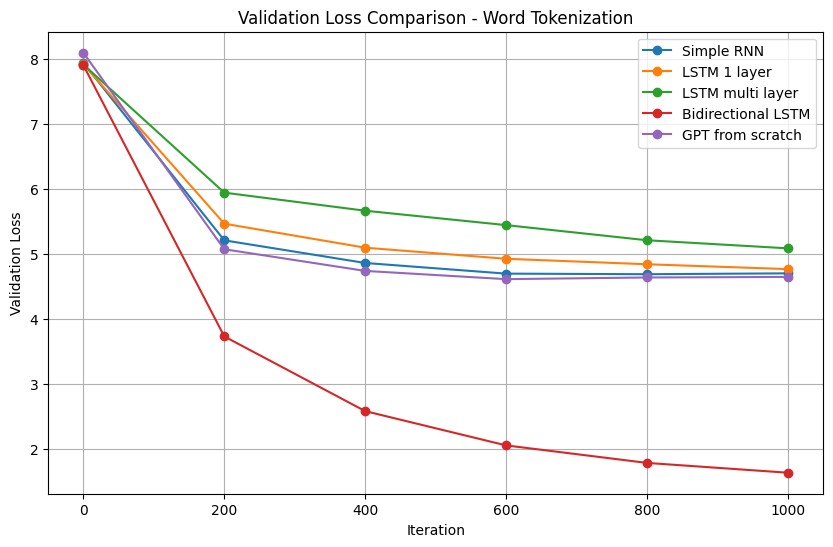

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for history in all_histories:
    plt.plot(
        history["iter"],
        history["val_loss"],
        marker="o",
        label=history["model"][-1]
    )

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison - Word Tokenization")
plt.legend()
plt.grid(True)
plt.show()